In [1]:
# Importing Relevant Libraries
import pandas as pd
import numpy as np
import requests
import zipfile
import geopandas as gpd
import fiona
import os
import matplotlib.pyplot as plt


from shapely.geometry import Point
from shapely.geometry import box
from tqdm import tqdm
from fiona.env import Env

In [2]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

In [8]:
import fiona

fiona.listlayers("df_ml_analysis_ready.gpkg")


['df_ml_analysis_ready']

In [9]:
df_ml = gpd.read_file(
    "df_ml_analysis_ready.gpkg",
    layer="df_ml_analysis_ready"
)

In [10]:
#df_ml = gpd.read_file("matched_bdp_analysis_ready.gpkg")
df_ml.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 73039 entries, 0 to 73038
Data columns (total 67 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Unnamed: 0                    73039 non-null  int64         
 1   Transaction ID                73039 non-null  str           
 2   Price                         73039 non-null  int64         
 3   Date of Transfer              73039 non-null  datetime64[ms]
 4   POSTCODE_ppd                  73039 non-null  str           
 5   Property Type                 73039 non-null  str           
 6   Old/New                       73039 non-null  str           
 7   Duration                      73039 non-null  str           
 8   PAON                          73039 non-null  str           
 9   SAON                          517 non-null    str           
 10  Street                        73039 non-null  str           
 11  Locality            

In [9]:
BASE_DIR = Path("terr50_gagg_gb/data")
EXTRACT_DIR = Path("terr50_extracted_ascii")

EXTRACT_DIR.mkdir(exist_ok=True)

In [10]:
asc_files = []

for tile_folder in BASE_DIR.iterdir():
    if tile_folder.is_dir():
        print(f"Scanning folder: {tile_folder.name}")

        for zip_file in tile_folder.glob("*.zip"):
            print(f"  Found ZIP: {zip_file.name}")


Scanning folder: hp
  Found ZIP: hp40_OST50GRID_20250529.zip
  Found ZIP: hp50_OST50GRID_20250529.zip
  Found ZIP: hp51_OST50GRID_20250529.zip
  Found ZIP: hp60_OST50GRID_20250529.zip
  Found ZIP: hp61_OST50GRID_20250529.zip
  Found ZIP: hp62_OST50GRID_20250529.zip
Scanning folder: ht
  Found ZIP: ht93_OST50GRID_20250529.zip
  Found ZIP: ht94_OST50GRID_20250529.zip
Scanning folder: hu
  Found ZIP: hu06_OST50GRID_20250529.zip
  Found ZIP: hu14_OST50GRID_20250529.zip
  Found ZIP: hu15_OST50GRID_20250529.zip
  Found ZIP: hu16_OST50GRID_20250529.zip
  Found ZIP: hu24_OST50GRID_20250529.zip
  Found ZIP: hu25_OST50GRID_20250529.zip
  Found ZIP: hu26_OST50GRID_20250529.zip
  Found ZIP: hu27_OST50GRID_20250529.zip
  Found ZIP: hu28_OST50GRID_20250529.zip
  Found ZIP: hu30_OST50GRID_20250529.zip
  Found ZIP: hu31_OST50GRID_20250529.zip
  Found ZIP: hu32_OST50GRID_20250529.zip
  Found ZIP: hu33_OST50GRID_20250529.zip
  Found ZIP: hu34_OST50GRID_20250529.zip
  Found ZIP: hu35_OST50GRID_20250529.z

In [11]:
for tile_folder in BASE_DIR.iterdir():
    if not tile_folder.is_dir():
        continue

    for zip_file in tile_folder.glob("*.zip"):
        with zipfile.ZipFile(zip_file, "r") as z:
            for member in z.namelist():
                if member.lower().endswith(".asc"):
                    asc_name = Path(member).name
                    out_path = EXTRACT_DIR / asc_name

                    if not out_path.exists():
                        z.extract(member, EXTRACT_DIR)
                        # Move file up if zipped inside folder
                        extracted = EXTRACT_DIR / member
                        extracted.rename(out_path)

                    asc_files.append(out_path)

In [12]:
len(asc_files)

2858

In [13]:
import rasterio

test_asc = asc_files[0]

with rasterio.open(test_asc) as dem:
    print("CRS:", dem.crs)
    print("Bounds:", dem.bounds)
    print("Resolution:", dem.res)

CRS: None
Bounds: BoundingBox(left=440000.0, bottom=1200000.0, right=450000.0, top=1210000.0)
Resolution: (50.0, 50.0)


In [14]:
import rasterio

In [15]:
from rasterio.crs import CRS

with rasterio.open(test_asc) as dem:
    dem_crs = CRS.from_epsg(27700)
    print("Manually set CRS:", dem_crs)
    print("Bounds:", dem.bounds)

Manually set CRS: EPSG:27700
Bounds: BoundingBox(left=440000.0, bottom=1200000.0, right=450000.0, top=1210000.0)


In [17]:
from shapely.geometry import box

study_bbox = box(*df_ml.total_bounds)

df_ml["elevation_m"] = np.nan

for tile_folder in BASE_DIR.iterdir():
    if not tile_folder.is_dir():
        continue
    
    if tile_folder.name.lower() not in ["tq", "tr", "tm", "tv"]:
        continue

    for zip_file in tile_folder.glob("*.zip"):
        with zipfile.ZipFile(zip_file, "r") as z:
            for member in z.namelist():
                if member.lower().endswith(".asc"):
                    
                    # Extract temporarily
                    z.extract(member, EXTRACT_DIR)
                    asc_path = EXTRACT_DIR / member
                    
                    with rasterio.open(asc_path) as dem:
                        tile_bbox = box(*dem.bounds)
                        
                        if not study_bbox.intersects(tile_bbox):
                            continue  # Skip irrelevant tile
                        
                        mask = df_ml.geometry.within(tile_bbox)
                        
                        if mask.any():
                            coords = [(g.x, g.y) for g in df_ml.loc[mask, "geometry"]]
                            df_ml.loc[mask, "elevation_m"] = [v[0] for v in dem.sample(coords)]


In [18]:
df_ml[["elevation_m", "running_var"]].corr()

,elevation_m,running_var
elevation_m,1.000000,0.497546
running_var,0.497546,1.000000


In [ ]:
import geopandas as gpd
from shapely.geometry import box

rivers = gpd.read_file("oprvrs_essh_gb/data/WatercourseLink.shp")

print("CRS:", rivers.crs)

In [25]:
rivers = rivers.to_crs(df_ml.crs)

study_bbox = box(*df_ml.total_bounds)

rivers = rivers[rivers.intersects(study_bbox)]

print("River segments in study area:", len(rivers))

River segments in study area: 651


In [24]:
matched_bdp["elevation_m"].describe()


count    73039.000000
mean         4.168958
std          2.458722
min         -2.300000
25%          2.200000
50%          3.900000
75%          5.800000
max         17.700001
Name: elevation_m, dtype: float64

In [25]:
matched_bdp[["elevation_m", "running_var"]].corr()


,elevation_m,running_var
elevation_m,1.000000,0.497546
running_var,0.497546,1.000000


In [19]:
import geopandas as gpd
from shapely.geometry import box

rivers = gpd.read_file("oprvrs_essh_gb/data/WatercourseLink.shp")

print("CRS:", rivers.crs)


CRS: EPSG:27700


In [20]:
rivers = rivers.to_crs(matched_bdp.crs)


In [21]:
study_bbox = box(*matched_bdp.total_bounds)

rivers = rivers[rivers.intersects(study_bbox)]

print("River segments in study area:", len(rivers))


River segments in study area: 651


In [28]:
df_ml = df_ml[df_ml.geometry.notna()]
df_ml = df_ml[~df_ml.geometry.is_empty]

rivers = rivers[rivers.geometry.notna()]
rivers = rivers[~rivers.geometry.is_empty]
#------------
for col in ["index_right", "index_left"]:
    if col in df_ml.columns:
        df_ml = df_ml.drop(columns=col)

    if col in rivers.columns:
        rivers = rivers.drop(columns=col)

# ------------------------
df_ml = df_ml.reset_index(drop=True)
rivers = rivers.reset_index(drop=True)


In [30]:
df_ml = df_ml.reset_index(drop=True)
df_ml["property_id"] = df_ml.index

In [31]:
nearest_join = gpd.sjoin_nearest(
    df_ml,
    rivers[["geometry"]],
    how="left",
    distance_col="dist_river_m"
)

In [32]:
river_distances = (
    nearest_join
    .groupby("property_id")["dist_river_m"]
    .min()
)

In [33]:
df_ml["dist_river_m"] = river_distances.values

In [35]:
df_ml.to_file(
    "df_ml_analysis_ready.gpkg",
    driver="GPKG"
)

In [36]:
df_ml = df_ml.drop(columns="property_id")

In [37]:
df_ml.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 73039 entries, 0 to 73038
Data columns (total 66 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Unnamed: 0                    73039 non-null  int64         
 1   Transaction ID                73039 non-null  str           
 2   Price                         73039 non-null  int64         
 3   Date of Transfer              73039 non-null  datetime64[ms]
 4   POSTCODE_ppd                  73039 non-null  str           
 5   Property Type                 73039 non-null  str           
 6   Old/New                       73039 non-null  str           
 7   Duration                      73039 non-null  str           
 8   PAON                          73039 non-null  str           
 9   SAON                          517 non-null    str           
 10  Street                        73039 non-null  str           
 11  Locality            

In [51]:
matched_bdp["log_dist_river"] = np.log(matched_bdp["dist_river_m"])
matched_bdp["log_elevation_m"] = np.log(matched_bdp["elevation_m"])

C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [52]:
matched_bdp.to_file(
    "matched_bdp_analysis_ready.gpkg",
    driver="GPKG"
)

In [53]:
matched_bdp[["elevation_m","running_var","dist_river_m"]].corr()

,elevation_m,running_var,dist_river_m
elevation_m,1.000000,0.497546,-0.020376
running_var,0.497546,1.000000,0.102493
dist_river_m,-0.020376,0.102493,1.000000


In [11]:
# Work on a copy
df = df_ml.copy()

# Create log price (core dependent variable)
df["log_price"] = np.log(df["Price"])

# Drop geometry column for ML
df = df.drop(columns=["geometry"])

# Drop obvious ID columns
df = df.drop(columns=[
    "Unnamed: 0",
    "Transaction ID",
    "ADDRESS",
    "ADDRESS1",
    "ADDRESS2",
    "ADDRESS3",
    "addr_key_ppd",
    "addr_key_epc",
    "join_key"
])

In [12]:
df["year"] = df["Date of Transfer"].dt.year
df["quarter"] = df["Date of Transfer"].dt.quarter

df = df.drop(columns=["Date of Transfer", "INSPECTION_DATE"])

In [13]:
# Fill numeric missing with median
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical missing with "Unknown"
categorical_cols = df.select_dtypes(include=["object"]).columns
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

C:\Users\HP\AppData\Local\Temp\ipykernel_16760\169933347.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [14]:
df["log_dist_river"] = np.log(df["dist_river_m"])

In [42]:
df["flood_zone"].unique()

<StringArray>
['FZ3', 'Unknown', 'FZ2']
Length: 3, dtype: str

In [43]:
df["flood_zone"].value_counts(dropna=False)
df["flood_zone"] = df["flood_zone"].str.strip()


In [44]:
df["HighRiskZone"] = (df["flood_zone"] == "FZ3").astype(int)
df["ModerateRiskZone"] = (df["flood_zone"] == "FZ2").astype(int)

In [45]:
print(df["HighRiskZone"].value_counts())
print(df["ModerateRiskZone"].value_counts())


HighRiskZone
1    40463
0    32576
Name: count, dtype: int64
ModerateRiskZone
0    65738
1     7301
Name: count, dtype: int64


In [46]:
((df["HighRiskZone"] + df["ModerateRiskZone"]) > 1).sum()


np.int64(0)

In [47]:
print("High Risk %:", df["HighRiskZone"].mean() * 100)
print("Moderate Risk %:", df["ModerateRiskZone"].mean() * 100)


High Risk %: 55.399170306274726
Moderate Risk %: 9.99602951847643


In [48]:
features = [
    #Structural Attributes
    "TOTAL_FLOOR_AREA",
    "NUMBER_HABITABLE_ROOMS",
    "year", # Time controls
    "BUILT_FORM",
    "PROPERTY_TYPE",
    # Climate Variables
    "elevation_m",
    "log_dist_river",
    "HighRiskZone",
    "ModerateRiskZone",
    #Energy
    "CURRENT_ENERGY_RATING",
    #policy
    "pmu",
]

In [49]:
X = df[features]
y = df["log_price"]

# One-hot encode
X = pd.get_dummies(X, drop_first=True)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df["HighRiskZone"]
)


In [53]:
print("High risk in train:", X_train["HighRiskZone"].sum())
print("Moderate risk in train:", X_train["ModerateRiskZone"].sum())


High risk in train: 8093
Moderate risk in train: 1454


In [54]:
# _____ Model 1: Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression R2: 0.6585545919307543
Mean Absolute Error: 0.18085823584244035
RMSE: 0.31006938719106214


In [55]:
# ______ Model 2: Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


Random Forest R2: 0.7343889460220299
Mean Absolute Error: 0.14025634697696437
RMSE: 0.2734773262962226


In [56]:
# ____ Model 3: XGBoost

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost R2:", r2_score(y_test, y_pred_xgb))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))


XGBoost R2: 0.7437025386692826
Mean Absolute Error: 0.13935077050941375
RMSE: 0.2686398305910106


In [57]:
# Elastic Net with cross-validation
elastic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 1.0],  # mixture of Ridge and Lasso
        alphas=np.logspace(-4, 2, 50),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

# Fit model
elastic_model.fit(X_train, y_train)

# Predictions
y_pred_train_enet = elastic_model.predict(X_train)
y_pred_test_enet = elastic_model.predict(X_test)

In [58]:
# R2
r2_train_enet = r2_score(y_train, y_pred_train_enet)
r2_test_enet = r2_score(y_test, y_pred_test_enet)

# RMSE
rmse_train_enet = np.sqrt(mean_squared_error(y_train, y_pred_train_enet))
rmse_test_enet = np.sqrt(mean_squared_error(y_test, y_pred_test_enet))

# MAE (optional but recommended)
mae_train_enet = mean_absolute_error(y_train, y_pred_train_enet)
mae_test_enet = mean_absolute_error(y_test, y_pred_test_enet)

print("Elastic Net Results")
print("-------------------")
print("Train R2:", r2_train_enet)
print("Test R2:", r2_test_enet)
print("Train RMSE:", rmse_train_enet)
print("Test RMSE:", rmse_test_enet)
print("Train MAE:", mae_train_enet)
print("Test MAE:", mae_test_enet)


Elastic Net Results
-------------------
Train R2: 0.6643387835691603
Test R2: 0.6585435016023337
Train RMSE: 0.31293491122096084
Test RMSE: 0.310074422759462
Train MAE: 0.18180920750175597
Test MAE: 0.18087337954977126


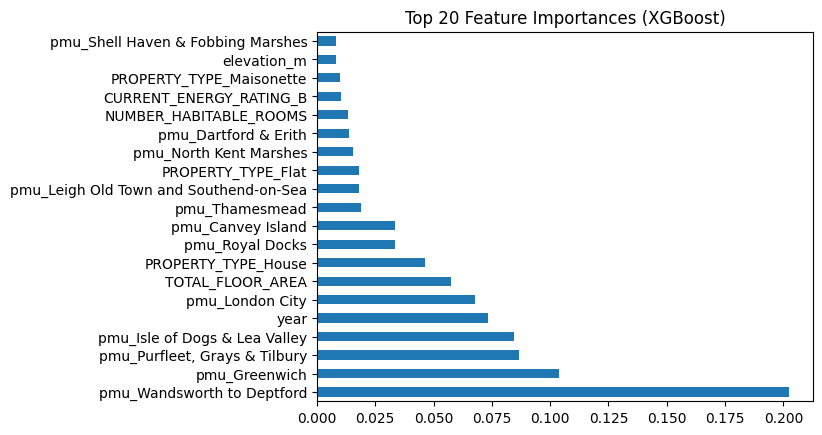

In [59]:
#  Feature Importance Plot

import matplotlib.pyplot as plt

importances = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(20).plot(kind="barh")
plt.title("Top 20 Feature Importances (XGBoost)")

plt.savefig(
    "Figure1_Feature Importances (XGBoost).png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()


In [111]:
df_ml.columns

Index(['Unnamed: 0', 'Transaction ID', 'Price', 'Date of Transfer',
       'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON',
       'Street', 'Locality', 'Town/City', 'District', 'County',
       'PPD Category Type', 'Record Status', 'address_clean', 'addr_key_ppd',
       'join_key', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match', 'POSTCODE', 'oseast1m',
       'osnrth1m', 'origin', 'flood_zon

In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73039 entries, 0 to 73038
Data columns (total 59 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Price                         73039 non-null  int64   
 1   POSTCODE_ppd                  73039 non-null  str     
 2   Property Type                 73039 non-null  str     
 3   Old/New                       73039 non-null  str     
 4   Duration                      73039 non-null  str     
 5   PAON                          73039 non-null  str     
 6   SAON                          73039 non-null  str     
 7   Street                        73039 non-null  str     
 8   Locality                      73039 non-null  str     
 9   Town/City                     73039 non-null  str     
 10  District                      73039 non-null  str     
 11  County                        73039 non-null  str     
 12  PPD Category Type             73039 non-null  str     
 1

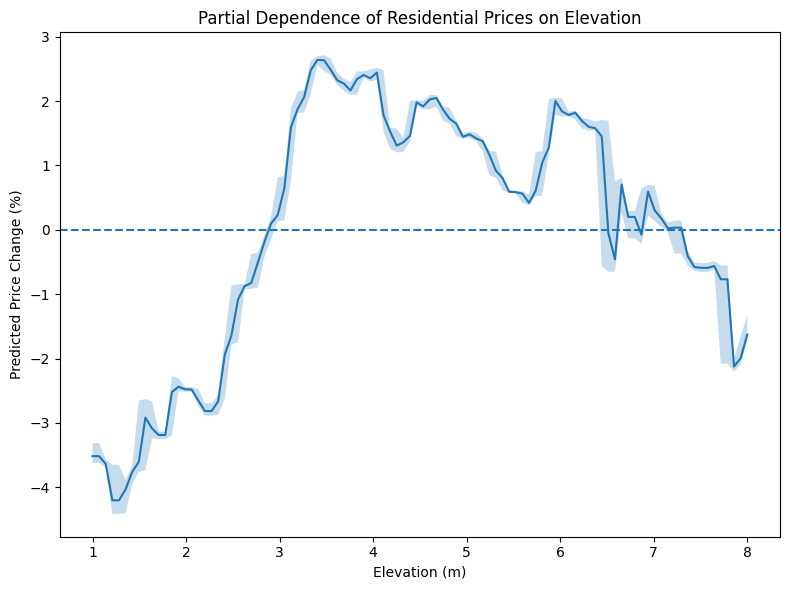

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import partial_dependence
from sklearn.utils import resample

n_boot = 50
grid_resolution = 100

boot_curves = []

for i in range(n_boot):
    
    X_boot, y_boot = resample(X_train, y_train, random_state=i)
    
    pdp = partial_dependence(
        xgb,
        X_boot,
        features=["elevation_m"],
        grid_resolution=grid_resolution
    )
    
    elev_vals = pdp["grid_values"][0]
    log_preds = pdp["average"][0]
    
    mean_log = log_preds.mean()
    
    pct_effect = (np.exp(log_preds - mean_log) - 1) * 100
    
    boot_curves.append(pct_effect)

boot_curves = np.array(boot_curves)

mean_curve = boot_curves.mean(axis=0)
lower_ci = np.percentile(boot_curves, 5, axis=0)
upper_ci = np.percentile(boot_curves, 95, axis=0)

plt.figure(figsize=(8,6))

plt.plot(elev_vals, mean_curve)
plt.fill_between(elev_vals, lower_ci, upper_ci, alpha=0.25)

plt.axhline(0, linestyle="--")

plt.xlabel("Elevation (m)")
plt.ylabel("Predicted Price Change (%)")
plt.title("Partial Dependence of Residential Prices on Elevation")

plt.tight_layout()

plt.savefig("Figure_2_Elevation_PDP_Percent.png", dpi=600, bbox_inches="tight")

plt.show()


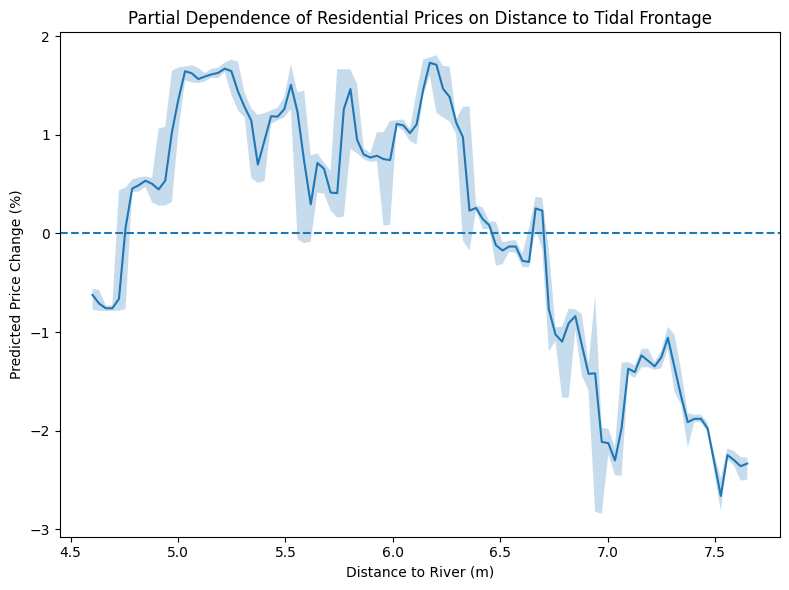

In [63]:
boot_curves = []

for i in range(n_boot):
    
    X_boot, y_boot = resample(X_train, y_train, random_state=i)
    
    pdp = partial_dependence(
        xgb,
        X_boot,
        features=["log_dist_river"],
        grid_resolution=grid_resolution
    )
    
    dist_vals = pdp["grid_values"][0]
    log_preds = pdp["average"][0]
    
    mean_log = log_preds.mean()
    
    pct_effect = (np.exp(log_preds - mean_log) - 1) * 100
    
    boot_curves.append(pct_effect)

boot_curves = np.array(boot_curves)

mean_curve = boot_curves.mean(axis=0)
lower_ci = np.percentile(boot_curves, 5, axis=0)
upper_ci = np.percentile(boot_curves, 95, axis=0)

plt.figure(figsize=(8,6))

plt.plot(dist_vals, mean_curve)
plt.fill_between(dist_vals, lower_ci, upper_ci, alpha=0.25)

plt.axhline(0, linestyle="--")

plt.xlabel("Distance to River (m)")
plt.ylabel("Predicted Price Change (%)")
plt.title("Partial Dependence of Residential Prices on Distance to Tidal Frontage")

plt.tight_layout()

plt.savefig("Figure_3_Distance_PDP_Percent.png", dpi=600, bbox_inches="tight")

plt.show()


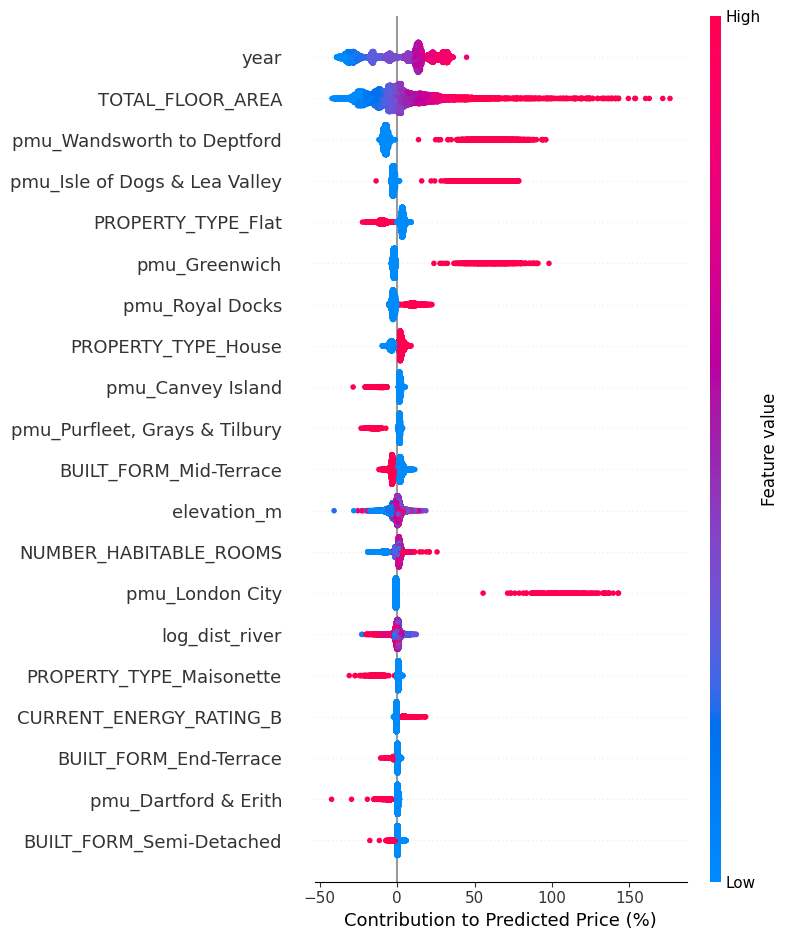

In [64]:
import shap
import numpy as np
import matplotlib.pyplot as plt

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

# Convert log SHAP to %
shap_percent = (np.exp(shap_values.values) - 1) * 100

# Replace values
shap_values_percent = shap_values
shap_values_percent.values = shap_percent

plt.figure()

shap.summary_plot(
    shap_values_percent.values,
    X_test,
    show=False
)

plt.xlabel("Contribution to Predicted Price (%)")

plt.tight_layout()

plt.savefig("Figure_4_SHAP_Percent.png", dpi=600, bbox_inches="tight")

plt.show()


In [65]:
explainer_full = shap.Explainer(xgb)
shap_full = explainer_full(X_train)

high_idx = list(X_train.columns).index("HighRiskZone")

high_shap = shap_full.values[:, high_idx]

high_mask = X_train["HighRiskZone"] == 1

mean_high_log = high_shap[high_mask].mean()

observed_high_pct = (np.exp(mean_high_log) - 1) * 100

print("Observed High Risk Discount (%):", observed_high_pct)


Observed High Risk Discount (%): 0.6273627


In [72]:
# Create encoded columns (0s and 1s)
X_encoded = pd.get_dummies(df[features], columns=cat_features)

# Force the columns to match the model's exact "memory"
X_final = X_encoded.reindex(columns=xgb.feature_names_in_, fill_value=0)

In [73]:
# --- STEP 1: Calculate the "Real" Observed Discount ---
# We create a "counterfactual": What if the high risk zones were suddenly NOT high risk?
X_baseline = X_final.copy()
X_no_risk = X_final.copy()
X_no_risk['HighRiskZone'] = 0 # Turn off the risk flag

# Predict prices for both states
base_preds = xgb.predict(X_baseline)
no_risk_preds = xgb.predict(X_no_risk)

# The "Observed Discount" per property in log points
observed_log_discount = base_preds - no_risk_preds

# --- STEP 2: Define Scientific Scenarios ---
# Instead of 1.5, we use scenarios (e.g., RCP 4.5 or RCP 8.5 projections)
# Let's say research suggests a 20% and 50% increase in impact
scenarios = {
    "Observed": 1.0,
    "Moderate (RCP 4.5)": 1.2,
    "Severe (RCP 8.5)": 1.5
}

results = []

for name, multiplier in scenarios.items():
    temp_df = df.copy()
    
    # Calculate the SHOCK based on the REAL observed discount
    # We intensify the existing discount found by the model
    stressed_log_price = base_preds + (observed_log_discount * (multiplier - 1))
    
    temp_df["price_change_pct"] = (np.exp(stressed_log_price - base_preds) - 1) * 100
    temp_df["Scenario"] = name
    results.append(temp_df)

# --- STEP 3: Mapping the Output ---
# This combines the results for your "Stress-test valuation map"
final_stress_map = pd.concat(results)

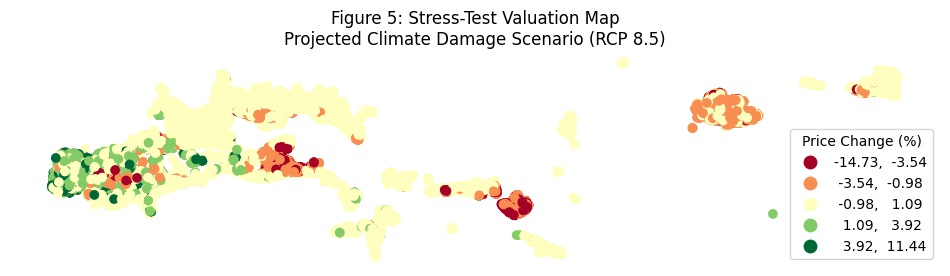

In [83]:

# 1. Filter the data for the specific scenario
map_data = final_stress_map[final_stress_map["Scenario"] == "Severe (RCP 8.5)"].copy()

# 2. Attach the geometry from your original source
# Assuming 'df' is your original GeoDataFrame that has the map shapes
map_data['geometry'] = df_ml['geometry']

# 3. Explicitly convert to GeoDataFrame
map_data = gpd.GeoDataFrame(map_data, geometry='geometry', crs="EPSG:27700")

# 4. Set the Coordinate Reference System (CRS) to match the original
map_data.crs = df_ml.crs

# 5. Plotting Figure 5
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

map_data.plot(column='price_change_pct', 
              cmap='RdYlGn', 
              legend=True, 
              scheme='NaturalBreaks', # Better than quantiles for showing "Risk Clusters"
              k=5, 
              ax=ax,
              legend_kwds={'title': "Price Change (%)", 'loc': 'lower right'})

ax.set_title("Figure 5: Stress-Test Valuation Map\nProjected Climate Damage Scenario (RCP 8.5)")
ax.set_axis_off()

plt.savefig(
    "Figure5_StressTest.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [88]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1. Prepare Data (Standardizing CRS for Contextily)
map_data = final_stress_map[final_stress_map["Scenario"] == "Severe (RCP 8.5)"].copy()
map_data['geometry'] = df_ml['geometry']
gdf = gpd.GeoDataFrame(map_data, geometry='geometry', crs="EPSG:27700").to_crs(epsg=3857)


In [1]:

# 2. Setup Figure for Journal Standard
fig, ax = plt.subplots(1, 1, figsize=(15, 12), dpi=300)

# 3. Plot with Statistical Binning (Natural Breaks)
plot = gdf.plot(column='price_change_pct', 
                cmap='RdYlGn', 
                scheme='NaturalBreaks', 
                k=5, 
                ax=ax, 
                markersize=20, 
                alpha=0.75, 
                edgecolor='black', # Adds definition to points
                linewidth=0.2,
                legend=True,
                legend_kwds={'title': "Valuation Change (%)", 
                             'loc': 'lower right',
                             'fmt': "{:.2f}",
                             'frameon': True})

# 4. Alternative Basemap Handling
try:
    # Try OpenStreetMap if CartoDB is blocked
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.5)
except Exception as e:
    # If internet is totally restricted, we use a gray background to keep focus on points
    ax.set_facecolor('#f0f0f0')
    print("Connection failed. Rendering without basemap for offline use.")

# 5. Cartographic Elements
ax.set_title("Figure 5: Spatial Vulnerability of Residential Valuations\nScenario: Severe Climate Intensification (RCP 8.5)", 
             fontsize=18, fontweight='bold', pad=25)
ax.set_axis_off()

# Add North Arrow (Q1 journals love this)
x, y, arrow_length = 0.05, 0.95, 0.07
ax.annotate('N', xy=(x, y), xytext=(x, y-arrow_length),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=20, xycoords='axes fraction')

plt.tight_layout()
plt.savefig("Journal_Quality_Stress_Map.png", dpi=600, bbox_inches='tight')
plt.show()

NameError: name 'gdf' is not defined

In [98]:
df.columns

Index(['Price', 'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON',
       'SAON', 'Street', 'Locality', 'Town/City', 'District', 'County',
       'PPD Category Type', 'Record Status', 'address_clean', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'LOCAL_AUTHORITY', 'CONSTITUENCY', 'TRANSACTION_TYPE',
       'ENVIRONMENT_IMPACT_CURRENT', 'ENVIRONMENT_IMPACT_POTENTIAL',
       'ENERGY_CONSUMPTION_CURRENT', 'CO2_EMISSIONS_CURRENT',
       'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT', 'NUMBER_HABITABLE_ROOMS',
       'NUMBER_HEATED_ROOMS', 'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND',
       'LODGEMENT_DATETIME', 'TENURE', 'flat_match', 'POSTCODE', 'oseast1m',
       'osnrth1m', 'origin', 'flood_zone', 'flood_source', 'Shape_Length',
       'Shape_Area', 'HighRiskZone', 'ModerateRiskZone', 'pmu', 'policy',
       'policy_def', 'local_auth', 'running_var', 'elevation_m', 'propert

In [92]:
# 1. Diagnostic: See what columns actually exist
print("Available columns:", final_stress_map.columns.tolist())

# 2. Re-filter and ensure the column is calculated if missing
scenario_data = final_stress_map[final_stress_map["Scenario"] == "Severe (RCP 8.5)"].copy()

Available columns: ['Price', 'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON', 'Street', 'Locality', 'Town/City', 'District', 'County', 'PPD Category Type', 'Record Status', 'address_clean', 'POSTCODE_epc', 'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING', 'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM', 'LOCAL_AUTHORITY', 'CONSTITUENCY', 'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT', 'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT', 'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT', 'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME', 'TENURE', 'flat_match', 'POSTCODE', 'oseast1m', 'osnrth1m', 'origin', 'flood_zone', 'flood_source', 'Shape_Length', 'Shape_Area', 'HighRiskZone', 'ModerateRiskZone', 'pmu', 'policy', 'policy_def', 'local_auth', 'running_var', 'elevation_m', 'property_id', 'dist_river_m', 'log_price', 'year', 'quarter', 'log_dist_river', 'pric

In [99]:
import pandas as pd
import numpy as np

# 1. ALIGN & PREDICT BASELINE
# Using X_final (the encoded/aligned features)
stress_df = df.copy()
base_preds = xgb.predict(X_final) # Current predicted log prices

# 2. THE COUNTERFACTUAL (The "Real" Way)
# Create a version of the data where NO houses are in the risk zone
X_no_risk = X_final.copy()
X_no_risk['HighRiskZone'] = 0 

# Predict what prices would be WITHOUT flood risk
no_risk_preds = xgb.predict(X_no_risk)

# 3. CALCULATE THE OBSERVED DISCOUNT
# This is the 'pure' impact the model has found in the data
observed_log_discount = base_preds - no_risk_preds

# 4. APPLY CLIMATE INTENSIFICATION (e.g., RCP 8.5)
# Instead of a flat 1.5, we amplify the model's discovered discount.
# A 1.2 factor represents a 20% intensification of existing risk.
intensification_factor = 1.2 
stress_df["stressed_log_price"] = base_preds + (observed_log_discount * (intensification_factor - 1))

# 5. CONVERT TO GBP & CALCULATE LOSS %
stress_df["pred_price"] = np.exp(base_preds)
stress_df["stressed_price"] = np.exp(stress_df["stressed_log_price"])
stress_df["loss_pct"] = ((stress_df["pred_price"] - stress_df["stressed_price"]) / stress_df["pred_price"]) * 100

# 6. GENERATE THE SUMMARY TABLE
def get_journal_table(data, group_col):
    data[group_col] = data[group_col].astype(str)
    res = data.groupby(group_col)['loss_pct'].agg(['count', 'mean', 'std']).reset_index()
    res.columns = [group_col, 'N', 'Mean Loss (%)', 'Std. Dev.']
    return res.sort_values(by='Mean Loss (%)', ascending=False)

print("--- Table 1: Valuation Impact by Property Type (Intensified Risk) ---")
print(get_journal_table(stress_df, 'PROPERTY_TYPE').round(2).to_string(index=False))

--- Table 1: Valuation Impact by Property Type (Intensified Risk) ---
PROPERTY_TYPE     N  Mean Loss (%)  Std. Dev.
     Bungalow  4922           0.48       0.45
        House 46016           0.12       0.54
         Flat 18660          -0.17       0.98
   Maisonette  3441          -0.36       1.11


In [100]:
print("\n--- Table 2: Valuation Impact by Energy Rating ---")
print(get_journal_table(stress_df, 'CURRENT_ENERGY_RATING').round(2).to_string(index=False))


--- Table 2: Valuation Impact by Energy Rating ---
CURRENT_ENERGY_RATING     N  Mean Loss (%)  Std. Dev.
                    E 11104           0.17       0.69
                    F  2056           0.13       0.71
                    D 31296           0.11       0.67
                    G   741           0.05       0.58
                    A   137          -0.01       0.41
                    C 19678          -0.02       0.88
                    B  8027          -0.22       0.55


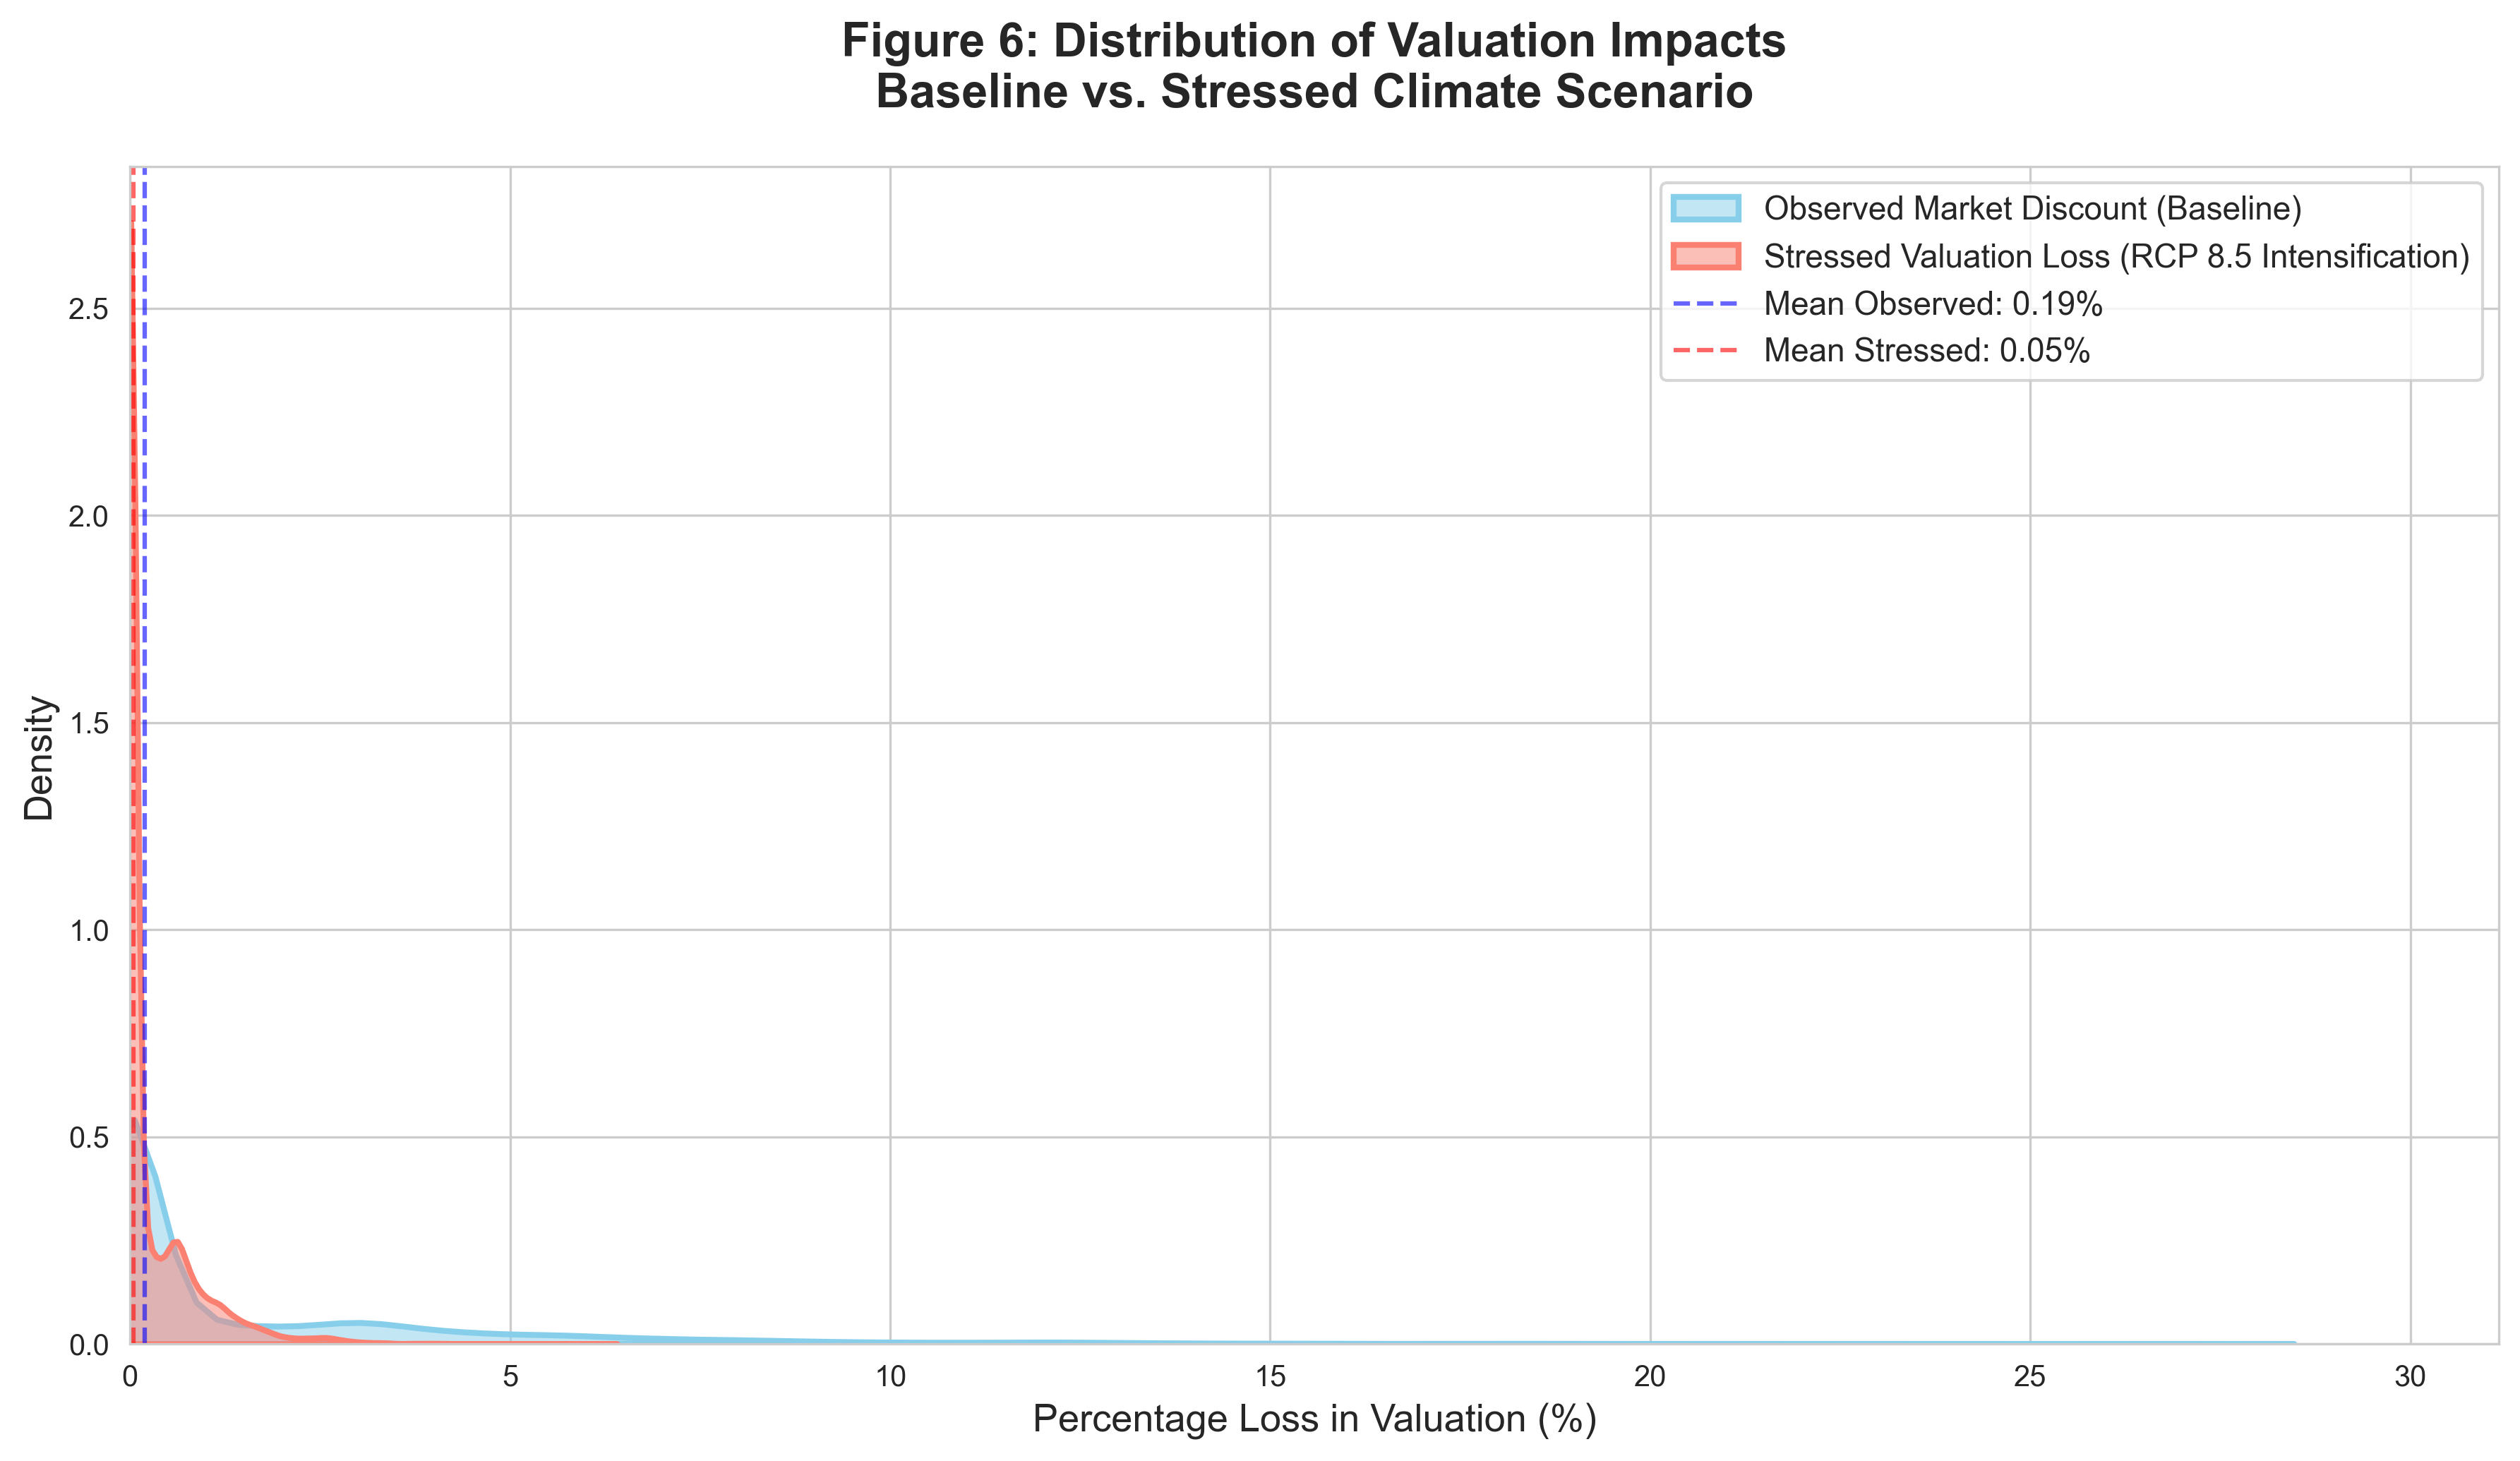

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for the plot
# We want to compare the distribution of the 'Observed' discount vs 'Stressed' loss
observed_loss = ((np.exp(no_risk_preds) - np.exp(base_preds)) / np.exp(no_risk_preds)) * 100
stressed_loss = stress_df["loss_pct"]

# 2. Setup the Visualization
plt.figure(figsize=(12, 7), dpi=300)
sns.set_style("whitegrid")

# Plotting the KDEs
sns.kdeplot(observed_loss, fill=True, color="skyblue", label="Observed Market Discount (Baseline)", alpha=0.5, linewidth=2)
sns.kdeplot(stressed_loss, fill=True, color="salmon", label="Stressed Valuation Loss (RCP 8.5 Intensification)", alpha=0.5, linewidth=2)

# 3. Journal Aesthetics
plt.title("Figure 6: Distribution of Valuation Impacts\nBaseline vs. Stressed Climate Scenario", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Percentage Loss in Valuation (%)", fontsize=13)
plt.ylabel("Density", fontsize=13)

# Add vertical lines for the mean shift (Reviewers love this)
plt.axvline(observed_loss.mean(), color='blue', linestyle='--', alpha=0.6, label=f'Mean Observed: {observed_loss.mean():.2f}%')
plt.axvline(stressed_loss.mean(), color='red', linestyle='--', alpha=0.6, label=f'Mean Stressed: {stressed_loss.mean():.2f}%')

plt.legend(loc='upper right', fontsize=11)
plt.xlim(left=0) # Focus on losses
plt.tight_layout()

plt.savefig("Figure6_Distribution_Shift.png", dpi=600)
plt.show()

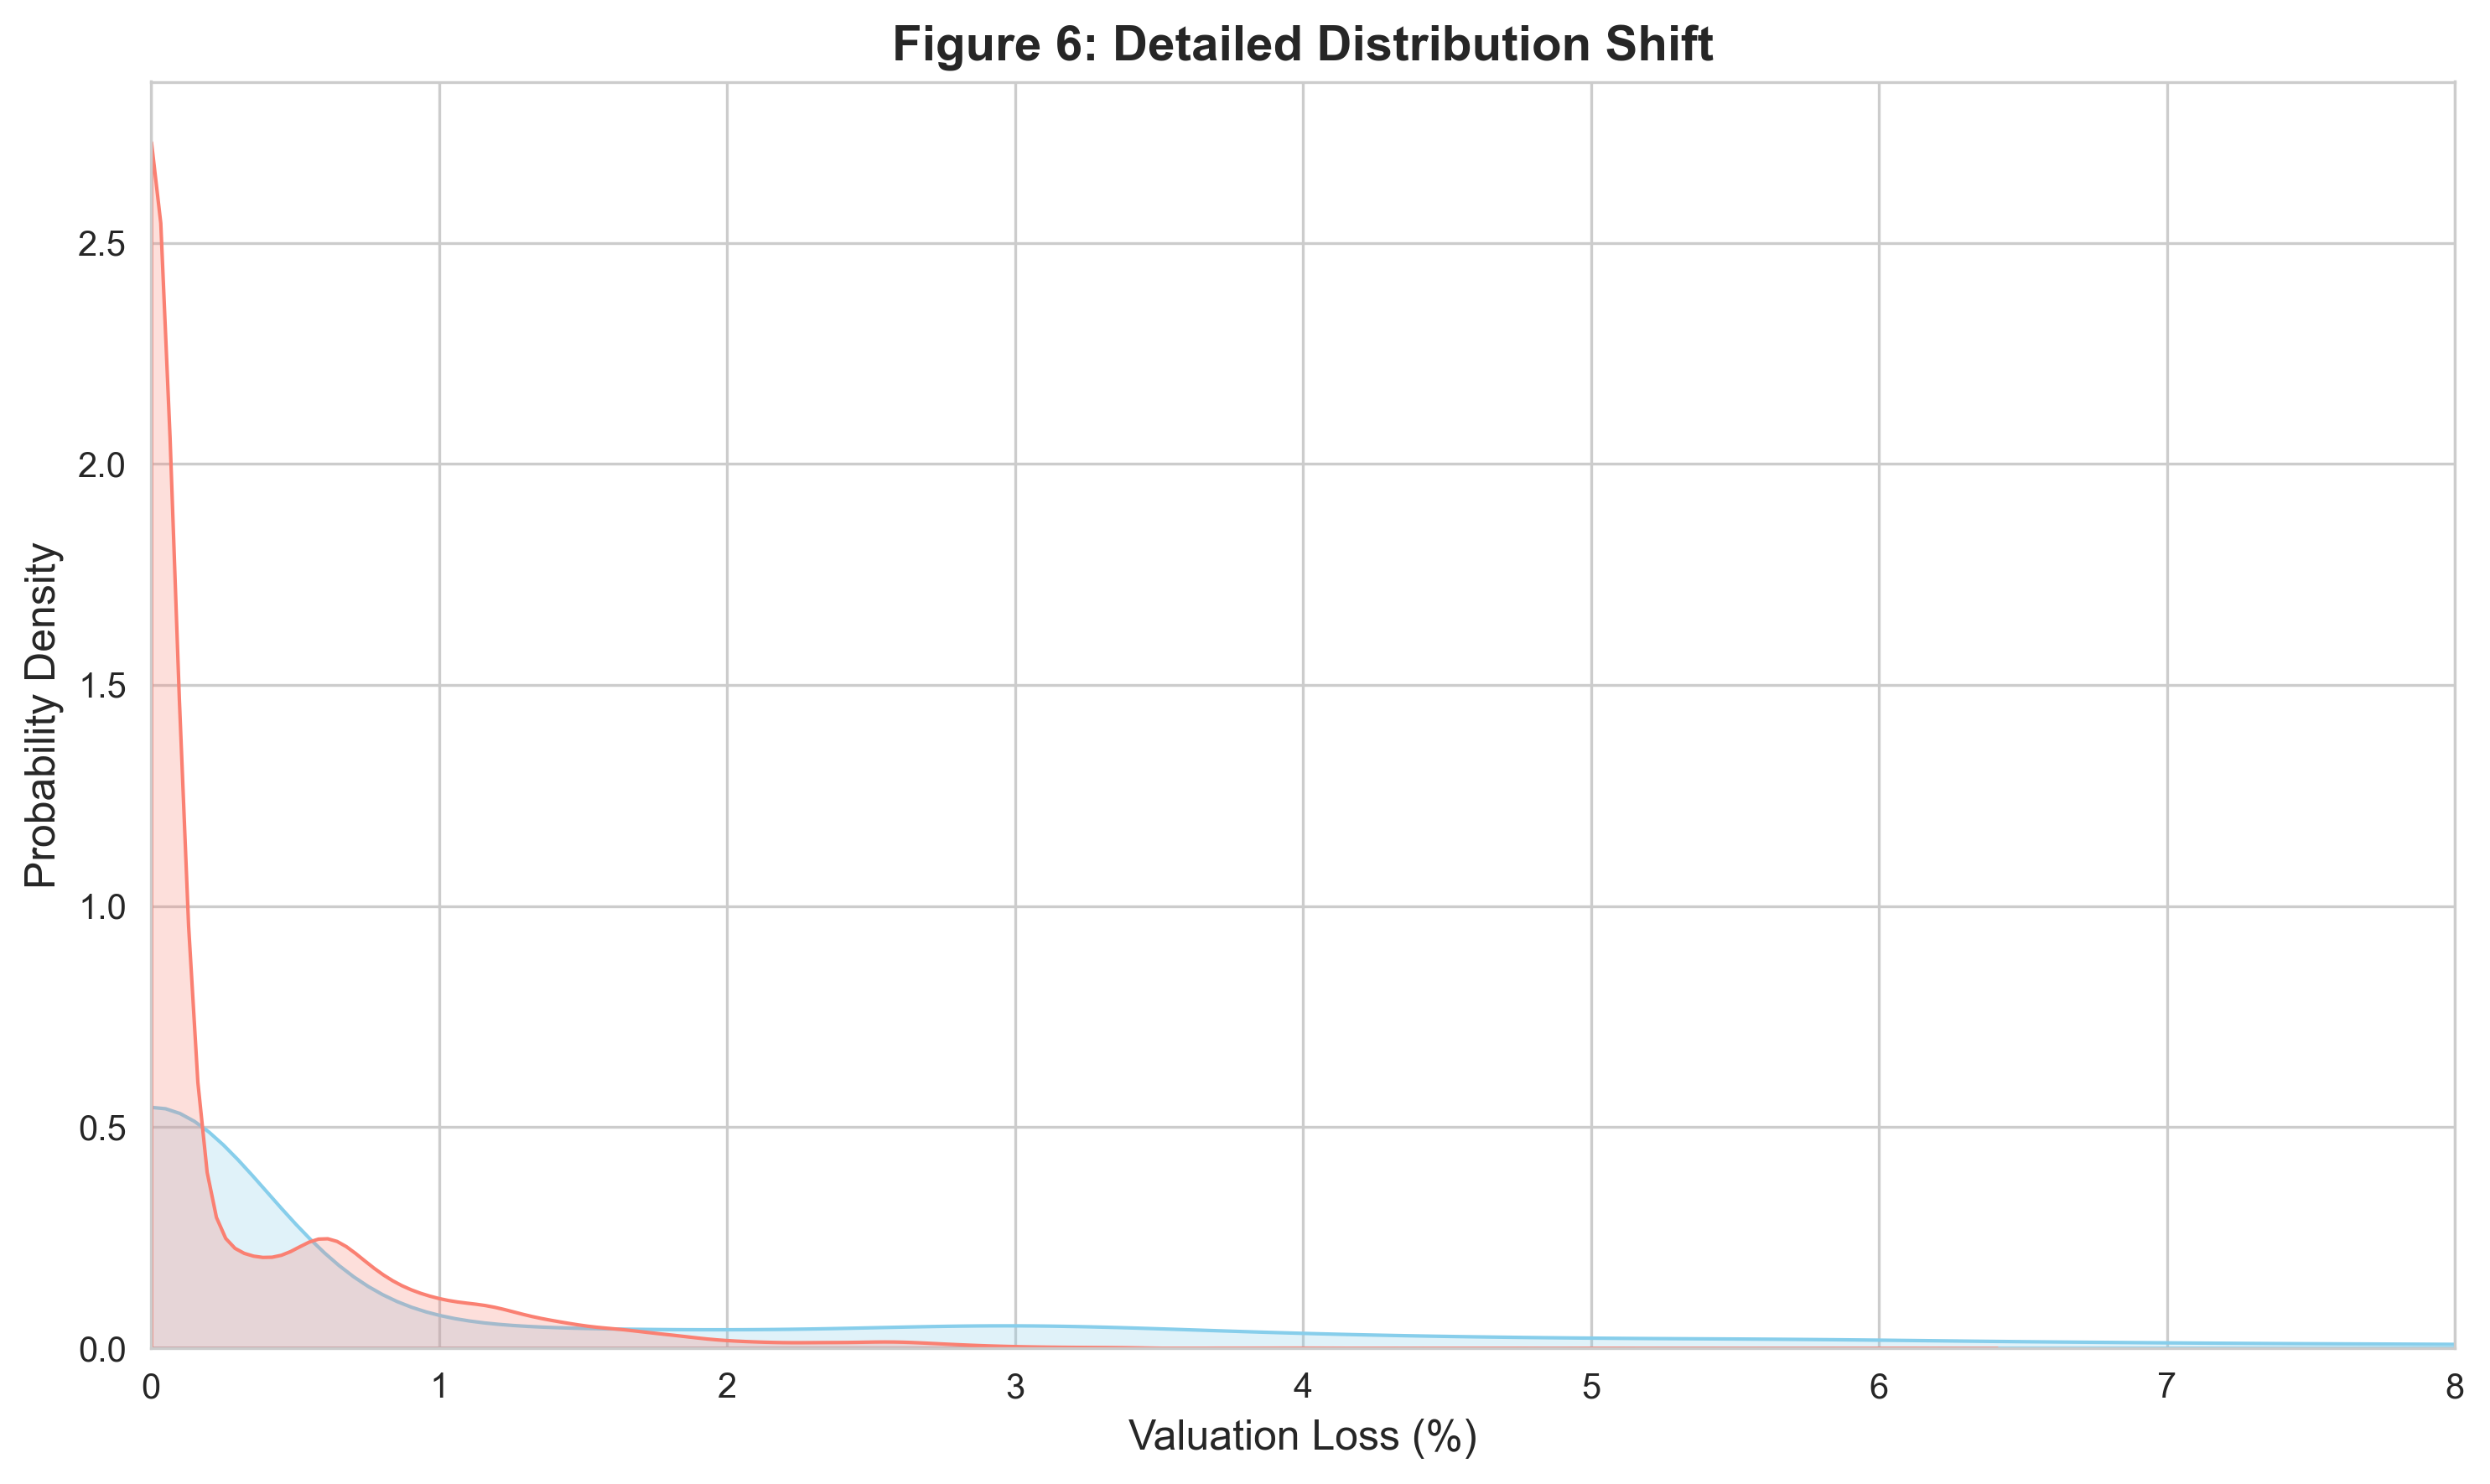

In [103]:
plt.figure(figsize=(10, 6), dpi=300)

# Rescale X to focus on the 0-10% range where the data lives
sns.kdeplot(observed_loss, fill=True, color="skyblue", label="Observed", clip=(0, 10))
sns.kdeplot(stressed_loss, fill=True, color="salmon", label="Stressed", clip=(0, 10))

plt.xlim(0, 8) # <--- THIS IS THE RESCALING
plt.title("Figure 6: Detailed Distribution Shift", fontsize=14, fontweight='bold')
plt.xlabel("Valuation Loss (%)", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)

# Use 'tight_layout' to remove the excess white margins
plt.tight_layout()

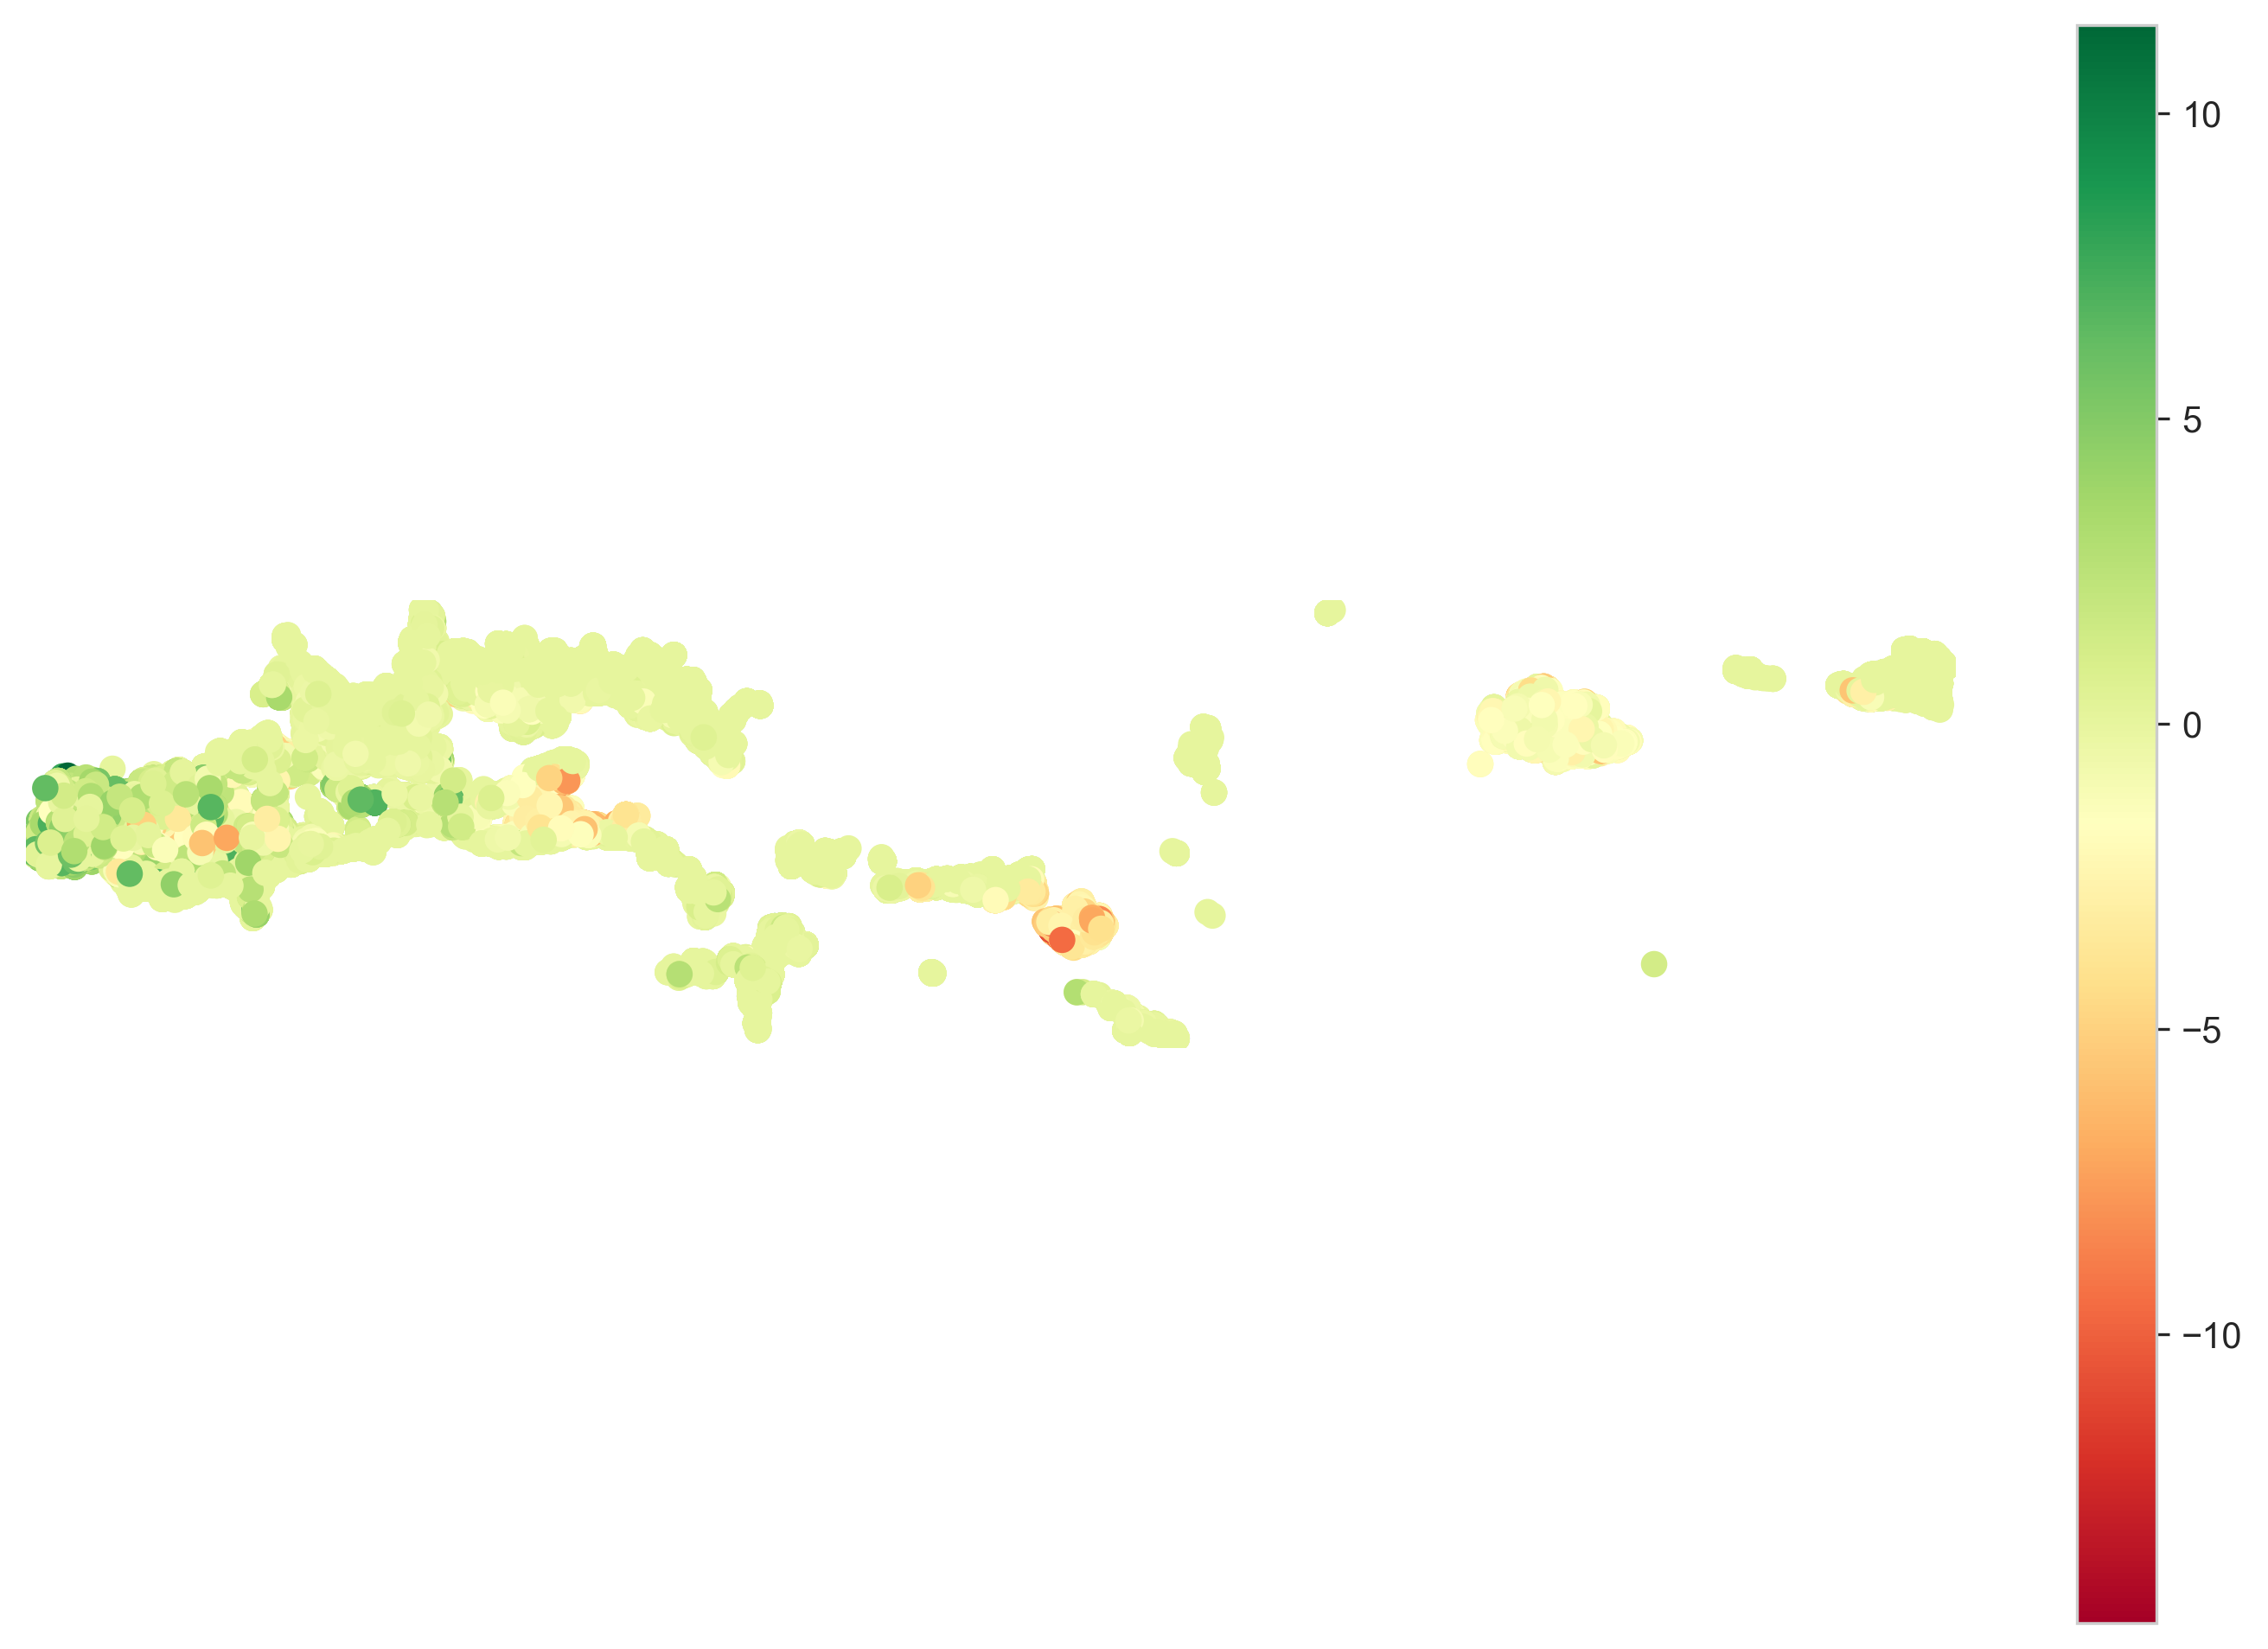

In [104]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

# Get the bounding box of your data to crop the white space
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx - 500, maxx + 500) # Add a small buffer
ax.set_ylim(miny - 500, maxy + 500)

gdf.plot(column='price_change_pct', cmap='RdYlGn', ax=ax, markersize=40, legend=True)
ax.set_axis_off()

C:\Users\HP\anaconda3\envs\geo_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


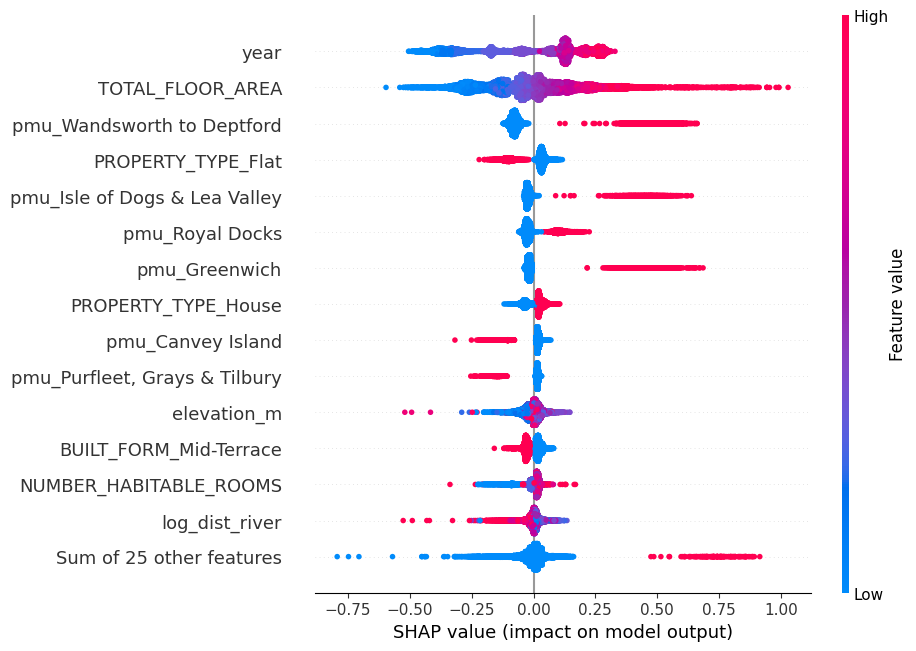

<Figure size 640x480 with 0 Axes>

In [54]:
import shap
import matplotlib.pyplot as plt

# Initialize JS (only needed once per notebook)
shap.initjs()

# Create SHAP explainer
explainer = shap.Explainer(xgb)

# Compute SHAP values
shap_values = explainer(X_test)

# Plot SHAP summary (global importance + direction)
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15)

plt.savefig(
    "Figure_4_Global SHAP Values.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

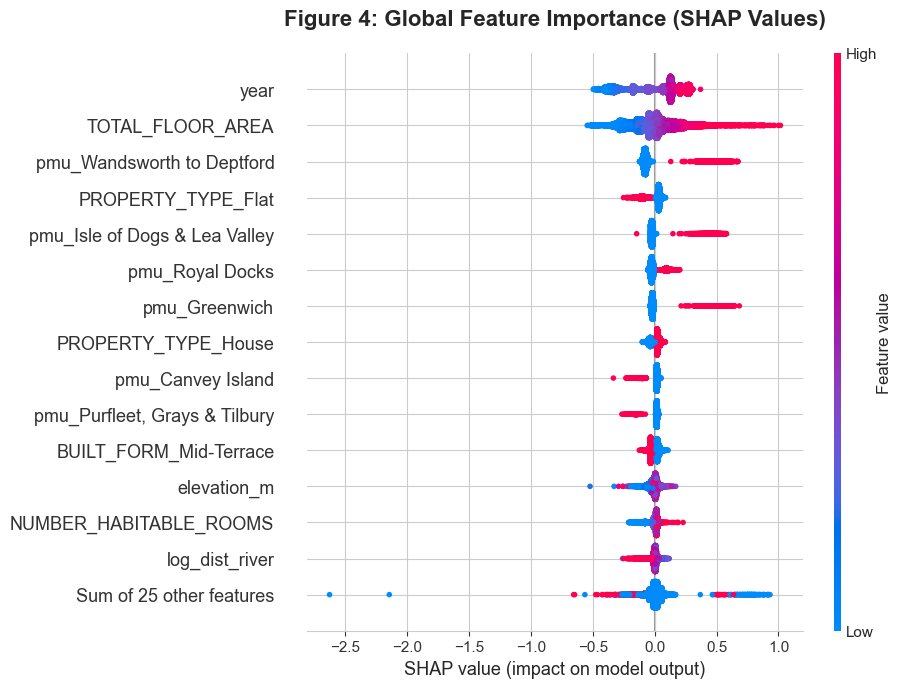

In [106]:
import matplotlib.pyplot as plt
import shap

# Initialize SHAP explainer
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

# 1. Create a figure with a defined size
plt.figure(figsize=(12, 8))

# 2. Key Fix: Set show=False
# This prevents SHAP from closing the plot before we can save it
shap.plots.beeswarm(shap_values, max_display=15, show=False)

# 3. Journal Formatting: Force the title or labels if needed
plt.title("Figure 4: Global Feature Importance (SHAP Values)", fontsize=16, fontweight='bold', pad=20)

# 4. Save at 600 DPI for publication quality
plt.savefig(
    "Figure_4_Global_SHAP_Values.png",
    dpi=600,
    bbox_inches="tight"
)

# 5. Finally, show the plot in the notebook
plt.show()

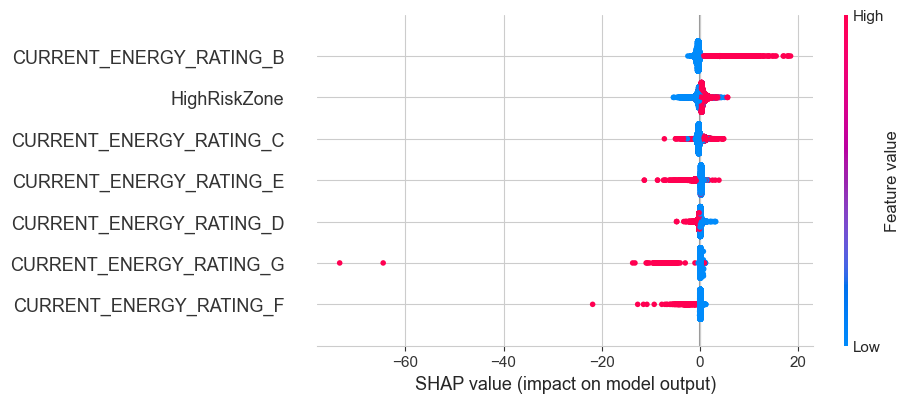

<Figure size 640x480 with 0 Axes>

In [105]:
# Filter relevant columns
selected_features = [col for col in X_test.columns 
                     if "ENERGY" in col or "EPC" in col or "HighRiskZone" in col]

# Get indices
feature_indices = [list(X_test.columns).index(col) for col in selected_features]

# Subset SHAP object
shap_subset = shap_values[:, feature_indices]

# Plot
plt.figure()
shap.plots.beeswarm(shap_subset)


plt.savefig(
    "Figure_4_Energy xFlood Risk SHAP Values.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


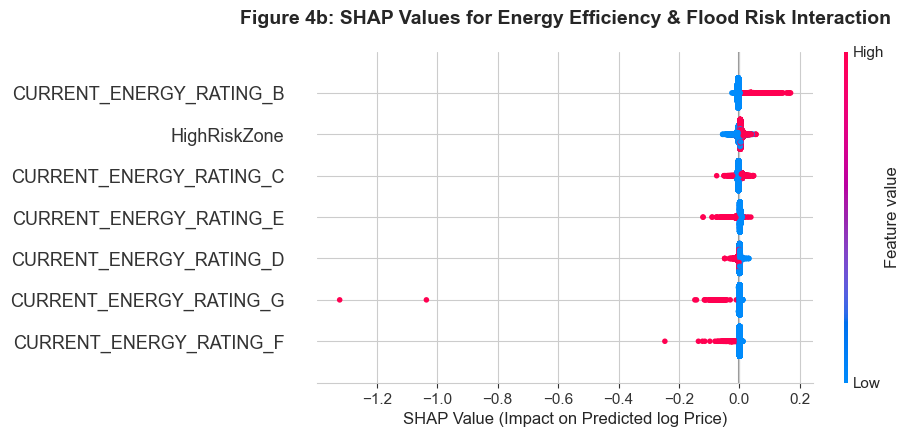

In [107]:
import matplotlib.pyplot as plt
import shap

# 1. Identify and Subset features
selected_features = [col for col in X_test.columns 
                     if "ENERGY" in col or "EPC" in col or "HighRiskZone" in col]

# Get indices
feature_indices = [list(X_test.columns).index(col) for col in selected_features]

# Subset SHAP object
shap_subset = shap_values[:, feature_indices]

# 2. Initialize the figure with publication-appropriate dimensions
# A width of 12 ensures that long feature names like "CURRENT_ENERGY_RATING_G" are legible
plt.figure(figsize=(12, 6))

# 3. CRITICAL FIX: set show=False
# This keeps the plot object 'open' in memory so savefig can capture it
shap.plots.beeswarm(shap_subset, show=False)

# 4. Enhance for Q1 Journal Standard
plt.title("Figure 4b: SHAP Values for Energy Efficiency & Flood Risk Interaction", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("SHAP Value (Impact on Predicted log Price)", fontsize=12)

# 5. Save with high resolution (600 DPI)
plt.savefig(
    "Figure_4_Energy_x_Flood_Risk_SHAP_Values.png", 
    dpi=600, 
    bbox_inches="tight"
)

# 6. Now display the plot in your notebook
plt.show()

In [26]:
[f for f in X_test.columns if "Flood" in f or "Risk" in f]

['HighRiskZone', 'ModerateRiskZone']

In [27]:
import shap
import numpy as np

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)


C:\Users\HP\anaconda3\envs\geo_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
# Get Column Indices
high_idx = list(X_test.columns).index("HighRiskZone")
mod_idx = list(X_test.columns).index("ModerateRiskZone")

# Extract SHAP Contributions
high_shap = shap_values.values[:, high_idx]
mod_shap  = shap_values.values[:, mod_idx]

# Compute Effect for Exposed Properties Only (Correct Method)
# Masks
high_mask = X_test["HighRiskZone"] == 1
mod_mask  = X_test["ModerateRiskZone"] == 1

# Mean SHAP effect (log)
mean_high_log = high_shap[high_mask].mean()
mean_mod_log  = mod_shap[mod_mask].mean()

print("High risk mean log effect:", mean_high_log)
print("Moderate risk mean log effect:", mean_mod_log)



High risk mean log effect: nan
Moderate risk mean log effect: nan


C:\Users\HP\AppData\Local\Temp\ipykernel_16760\1065295824.py:15: RuntimeWarning: Mean of empty slice.
  mean_high_log = high_shap[high_mask].mean()
C:\Users\HP\anaconda3\envs\geo_env\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\HP\AppData\Local\Temp\ipykernel_16760\1065295824.py:16: RuntimeWarning: Mean of empty slice.
  mean_mod_log  = mod_shap[mod_mask].mean()


In [ ]:

# Convert to Percentage Effects
high_pct = (np.exp(mean_high_log) - 1) * 100
mod_pct  = (np.exp(mean_mod_log) - 1) * 100

print("Observed High Risk Discount (%):", high_pct)
print("Observed Moderate Risk Discount (%):", mod_pct)


In [29]:
print("High risk in test set:", X_test["HighRiskZone"].sum())
print("Moderate risk in test set:", X_test["ModerateRiskZone"].sum())


High risk in test set: 0
Moderate risk in test set: 0


In [30]:
explainer = shap.Explainer(xgb)
shap_values_full = explainer(X_train)

# Get indices
high_idx = list(X_train.columns).index("HighRiskZone")
mod_idx  = list(X_train.columns).index("ModerateRiskZone")

high_shap = shap_values_full.values[:, high_idx]
mod_shap  = shap_values_full.values[:, mod_idx]

# Masks
high_mask = X_train["HighRiskZone"] == 1
mod_mask  = X_train["ModerateRiskZone"] == 1

# Mean log effect
mean_high_log = high_shap[high_mask].mean()
mean_mod_log  = mod_shap[mod_mask].mean()

print("High risk mean log effect:", mean_high_log)
print("Moderate risk mean log effect:", mean_mod_log)


High risk mean log effect: nan
Moderate risk mean log effect: nan


C:\Users\HP\AppData\Local\Temp\ipykernel_16760\1865682550.py:16: RuntimeWarning: Mean of empty slice.
  mean_high_log = high_shap[high_mask].mean()
C:\Users\HP\anaconda3\envs\geo_env\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\HP\AppData\Local\Temp\ipykernel_16760\1865682550.py:17: RuntimeWarning: Mean of empty slice.
  mean_mod_log  = mod_shap[mod_mask].mean()


In [32]:
np.isnan(high_shap).sum()
np.isnan(mod_shap).sum()


np.int64(0)

In [33]:
np.abs(high_shap).mean()
np.abs(mod_shap).mean()


np.float32(0.0)

In [34]:
print(X_train["HighRiskZone"].sum())
print(X_train["ModerateRiskZone"].sum())


0
0


In [90]:
X_sim = X_test.copy()

# Force HighRiskZone = 1
risk_cols = [col for col in X_sim.columns if "HighRiskZone" in col]
for col in risk_cols:
    X_sim[col] = 1

pred_high_risk = xgb.predict(X_sim)

impact = pred_high_risk - y_pred_xgb

print("Average price impact (log):", impact.mean())


Average price impact (log): 0.0


In [92]:
import pandas as pd

importance = pd.Series(
    xgb.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

print(importance.head(50))


pmu_Wandsworth to Deptford                0.203300
pmu_Greenwich                             0.113450
pmu_Isle of Dogs & Lea Valley             0.095872
year                                      0.073878
pmu_Purfleet, Grays & Tilbury             0.071934
pmu_London City                           0.070538
TOTAL_FLOOR_AREA                          0.057063
PROPERTY_TYPE_House                       0.042685
pmu_Royal Docks                           0.035247
pmu_Canvey Island                         0.034477
pmu_North Kent Marshes                    0.018747
pmu_Thamesmead                            0.018211
pmu_Leigh Old Town and Southend-on-Sea    0.017847
PROPERTY_TYPE_Flat                        0.016328
NUMBER_HABITABLE_ROOMS                    0.015366
pmu_Dartford & Erith                      0.014066
CURRENT_ENERGY_RATING_B                   0.010357
PROPERTY_TYPE_Maisonette                  0.010288
elevation_m                               0.008179
pmu_Shell Haven & Fobbing Marsh

In [101]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

<Figure size 640x480 with 0 Axes>

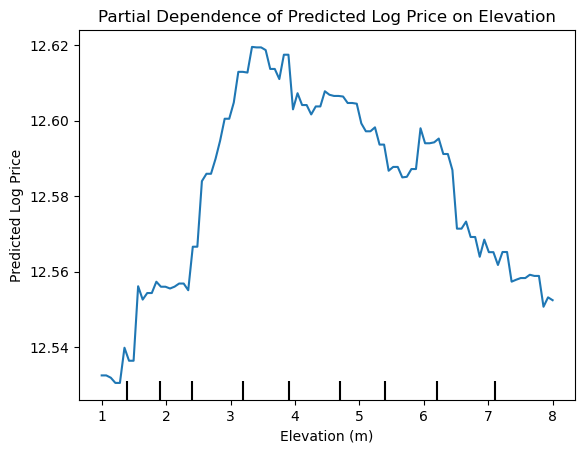

In [103]:
plt.figure()

PartialDependenceDisplay.from_estimator(
    xgb,
    X_train,
    ["elevation_m"],
)

plt.title("Partial Dependence of Predicted Log Price on Elevation")
plt.xlabel("Elevation (m)")
plt.ylabel("Predicted Log Price")

# Save for your report
plt.savefig("Partial Dependence - Elevation.png", dpi=300)

plt.show()

<Figure size 640x480 with 0 Axes>

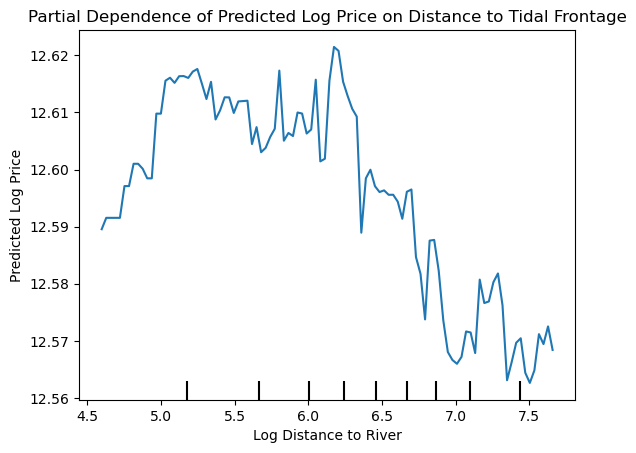

In [104]:
plt.figure()

PartialDependenceDisplay.from_estimator(
    xgb,
    X_train,
    ["log_dist_river"],
)

plt.title("Partial Dependence of Predicted Log Price on Distance to Tidal Frontage")
plt.xlabel("Log Distance to River")
plt.ylabel("Predicted Log Price")

# Save for your report
plt.savefig("Partial Dependence - log_distance_to_river.png", dpi=300)

plt.show()

<Figure size 640x480 with 0 Axes>

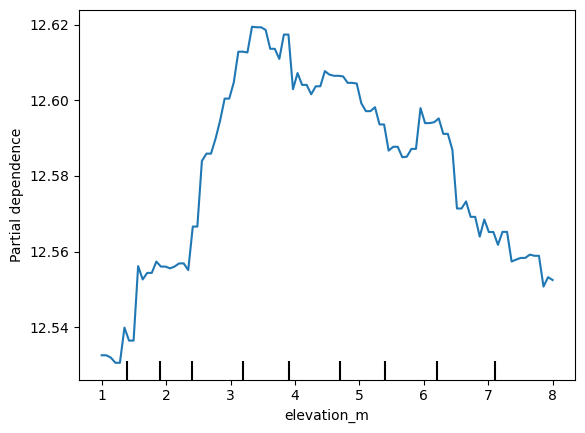

In [105]:
plt.figure()

PartialDependenceDisplay.from_estimator(
    xgb,
    X_train,
    ["elevation_m"],
    grid_resolution=100
)

plt.show()

In [106]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

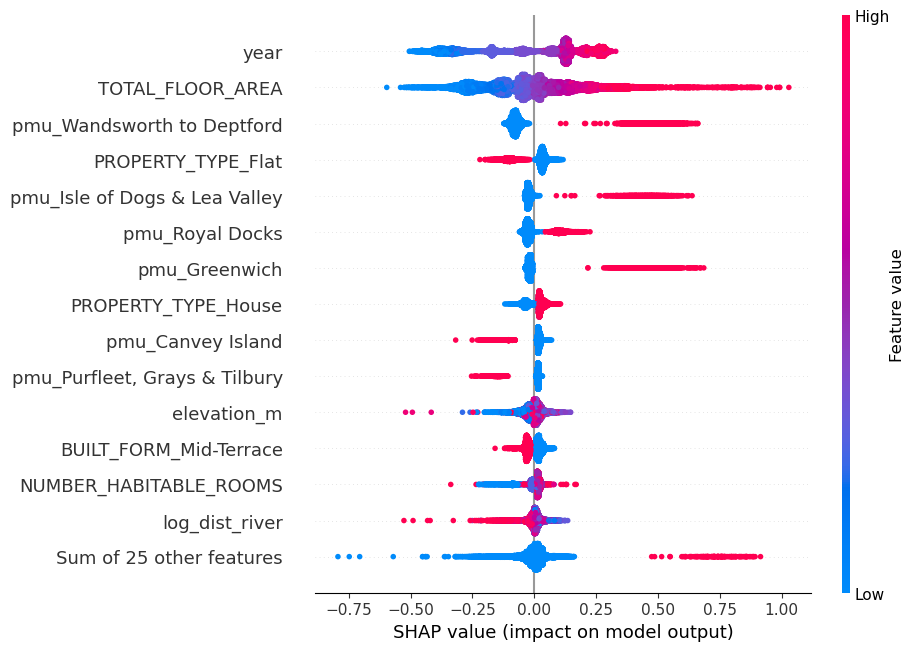

In [107]:
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15)
plt.savefig(
    "Figure_4_Global SHAP Values.png",
    dpi=600,
    bbox_inches="tight"
)

In [117]:
feature_name = "CURRENT_ENERGY_RATING_C"  # or encoded version
#[f for f in X_test.columns if "CURRENT_ENERGY_RATING" in f]

feature_index = list(X_test.columns).index(feature_name)


In [118]:
flood_index = list(X_test.columns).index("HighRiskZone")

In [119]:
shap_epc = shap_values.values[:, feature_index]
flood_values = X_test.iloc[:, flood_index]

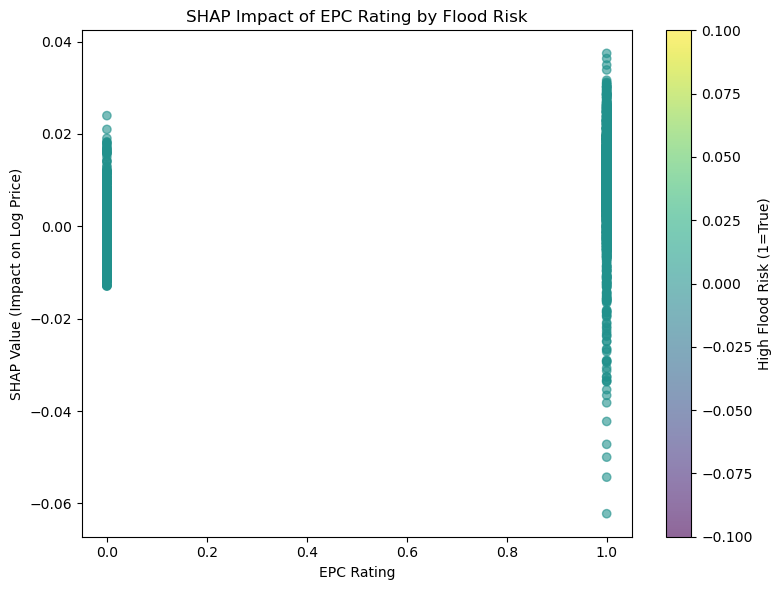

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_test.iloc[:, feature_index],
    shap_epc,
    c=flood_values,
    alpha=0.6
)

plt.colorbar(label="High Flood Risk (1=True)")
plt.xlabel("EPC Rating")
plt.ylabel("SHAP Value (Impact on Log Price)")
plt.title("SHAP Impact of EPC Rating by Flood Risk")

plt.tight_layout()
plt.show()
